In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


In [2]:
monthly = pd.read_csv("../data/processed/monthly_pin_raw.csv")
pin = pd.read_csv("../data/processed/pin_summary.csv")


In [3]:
# basic sanity checks

print("monthly_pin_raw shape:", monthly.shape)
print("pin_summary shape:", pin.shape)

print("\nmonthly_pin_raw columns:")
print(monthly.columns.tolist())

print("\npin_summary columns:")
print(pin.columns.tolist())

print("\nSample rows from monthly_pin_raw:")
monthly.head()

print("\nSample rows from pin_summary:")
pin.head()


monthly_pin_raw shape: (982, 11)
pin_summary shape: (96, 18)

monthly_pin_raw columns:
['state', 'district', 'pincode', 'month', 'age_0_5', 'age_5_17', 'age_18_greater', 'demo_age_5_17', 'demo_age_17_', 'bio_age_5_17', 'bio_age_17_']

pin_summary columns:
['pincode', 'top10_count', 'top25_count', 'top10_frac', 'top25_frac', 'biometric_only_count', 'biometric_only_fraction', 'median_BDR', 'mean_BDR', 'high_biometric_only', 'high_BDR', 'mean_CBCR', 'median_CBCR', 'low_CBCR', 'mean_ENROL_SAT', 'median_ENROL_SAT', 'is_saturated', 'months_total']

Sample rows from monthly_pin_raw:

Sample rows from pin_summary:


,pincode,top10_count,top25_count,top10_frac,top25_frac,biometric_only_count,biometric_only_fraction,median_BDR,mean_BDR,high_biometric_only,high_BDR,mean_CBCR,median_CBCR,low_CBCR,mean_ENROL_SAT,median_ENROL_SAT,is_saturated,months_total
0,400601,0,1,0.0,0.090909,4,0.363636,1.061303,1.024093,False,False,0.842027,0.905109,False,0.041322,0.045302,False,11
1,400602,0,1,0.0,0.090909,5,0.454545,0.892646,0.821139,True,False,0.863107,0.924399,False,0.023579,0.033360,False,11
2,400603,0,0,0.0,0.000000,5,0.454545,1.674895,1.819070,True,True,0.953061,0.966667,False,0.020997,0.020561,False,11
3,400604,0,0,0.0,0.000000,5,0.454545,1.262306,1.307597,True,False,0.925556,0.935342,False,0.044422,0.022979,False,11
4,400605,0,0,0.0,0.000000,4,0.363636,1.011805,1.026834,False,False,0.888354,0.897677,False,0.033496,0.025631,False,11


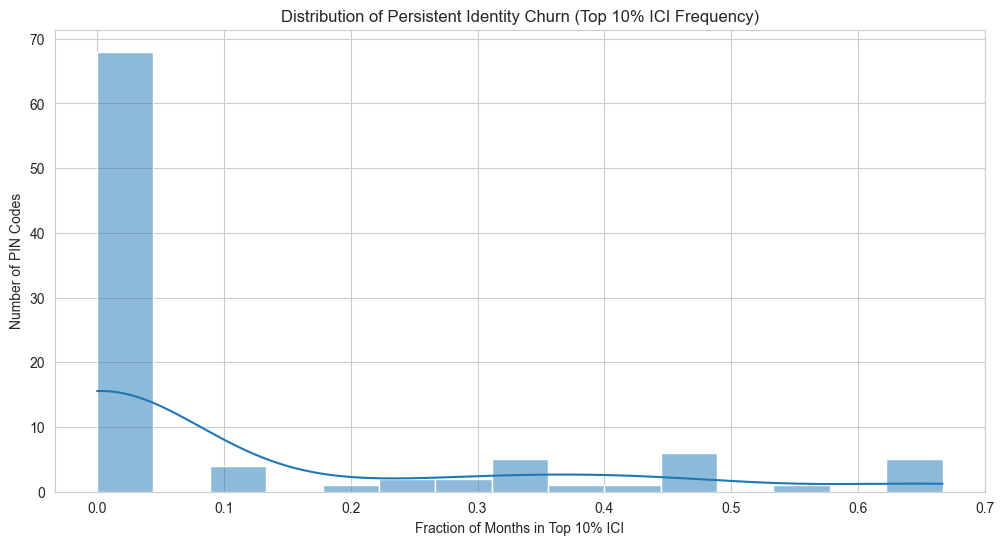

In [6]:
# Visualization 1: Distribution of persistent identity churn

sns.histplot(
    pin['top10_frac'],
    bins=15,
    kde=True
)

plt.title("Distribution of Persistent Identity Churn (Top 10% ICI Frequency)")
plt.xlabel("Fraction of Months in Top 10% ICI")
plt.ylabel("Number of PIN Codes")
plt.show()


In [7]:
# 1) Frequency table of exact fractions (how many PINs have each top10_frac)
freq_table = (
    pin[['pincode', 'months_total', 'top10_count', 'top10_frac']]
    .copy()
)
freq_summary = freq_table.groupby('top10_frac').agg(
    num_pins = ('pincode', 'nunique'),
    sample_pins = ('pincode', lambda s: ','.join(map(str, s.head(5))))
).reset_index().sort_values('top10_frac')

print("=== Frequency of top10_frac values ===")
print(freq_summary.to_string(index=False))

# 2) A readable table converting fraction -> (top10_count / months_total) for each PIN
print("\n=== Example per-PIN breakdown (top 20 sorted by top10_frac desc) ===")
examples = freq_table.sort_values('top10_frac', ascending=False).head(20)
print(examples.to_string(index=False))

# 3) Quick summary numbers (useful for doc bullets)
total_pins = len(pin)
never_in_top10 = (pin['top10_frac'] == 0).sum()
some_pins = total_pins - never_in_top10
print(f"\nTotal PINs: {total_pins}")
print(f"PINs never in top-10 ICI (top10_frac == 0): {never_in_top10}")
print(f"PINs at least once in top-10: {some_pins}")


=== Frequency of top10_frac values ===
 top10_frac  num_pins                        sample_pins
   0.000000        68 400601,400602,400603,400604,400605
   0.090909         1                             401201
   0.100000         2                      401207,401304
   0.111111         1                             401506
   0.200000         1                             401102
   0.222222         2                      401402,401502
   0.272727         1                             401202
   0.300000         1                             401602
   0.333333         5 401604,401610,401703,421312,421604
   0.363636         1                             401404
   0.400000         1                             401607
   0.444444         5 401401,401405,401601,401701,421303
   0.454545         1                             401501
   0.555556         1                             401503
   0.666667         5 401103,401403,401603,401605,401702

=== Example per-PIN breakdown (top 20 sorted by 

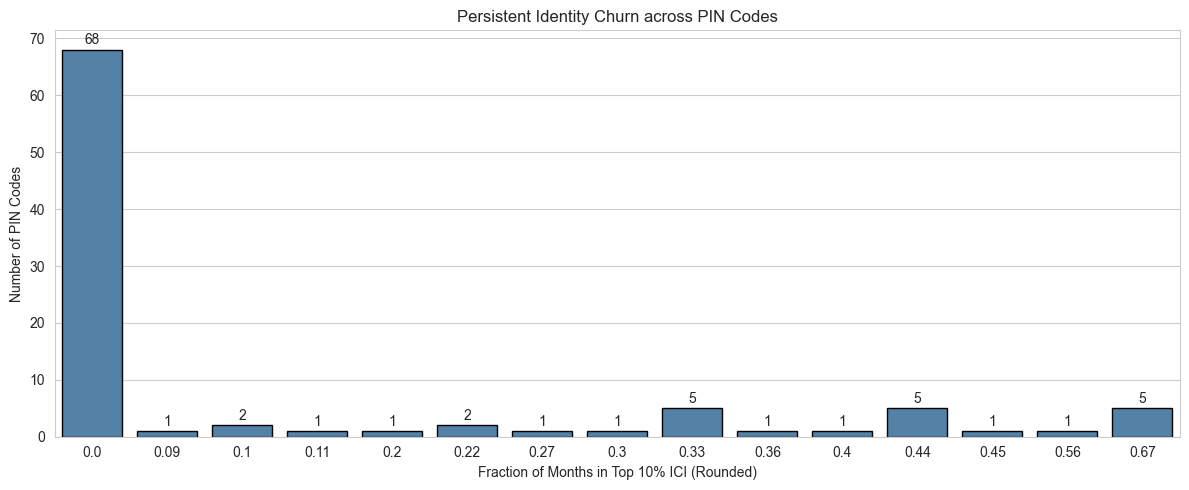

In [14]:
# Round top10_frac to 2 decimal places for plotting clarity

frac_counts_rounded = (
    pin.assign(top10_frac_round=pin['top10_frac'].round(2))
       .groupby('top10_frac_round')
       .agg(num_pins=('pincode', 'count'))
       .reset_index()
       .sort_values('top10_frac_round')
)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=frac_counts_rounded,
    x='top10_frac_round',
    y='num_pins',
    color='steelblue',
    edgecolor='black'
)

# Add numeric markers
for i, row in frac_counts_rounded.iterrows():
    plt.text(
        i,
        row['num_pins'] + 0.4,
        int(row['num_pins']),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Persistent Identity Churn across PIN Codes")
plt.xlabel("Fraction of Months in Top 10% ICI (Rounded)")
plt.ylabel("Number of PIN Codes")
plt.tight_layout()
plt.show()


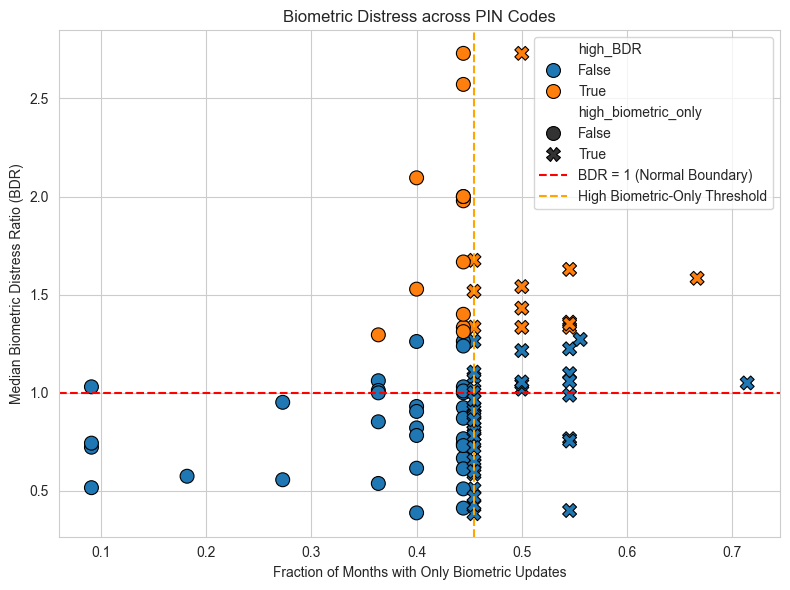

In [15]:
# Visualization 2: Biometric Distress Scatter Plot

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pin,
    x='biometric_only_fraction',
    y='median_BDR',
    hue='high_BDR',
    style='high_biometric_only',
    s=100,
    edgecolor='black'
)

# Reference lines (interpretation thresholds)
plt.axhline(1.0, color='red', linestyle='--', label='BDR = 1 (Normal Boundary)')
plt.axvline(
    pin['biometric_only_fraction'].quantile(0.75),
    color='orange',
    linestyle='--',
    label='High Biometric-Only Threshold'
)

plt.title("Biometric Distress across PIN Codes")
plt.xlabel("Fraction of Months with Only Biometric Updates")
plt.ylabel("Median Biometric Distress Ratio (BDR)")
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
# Numeric outputs for Biometric Distress scatter
# Run this cell and paste the text output here for validation.

import numpy as np
pd.options.display.max_rows = 200
pd.options.display.float_format = '{:.3f}'.format

# thresholds used in the plot
bdr_threshold = 1.0
bio_only_q75 = pin['biometric_only_fraction'].quantile(0.75)

print("Thresholds used:")
print(f" - BDR threshold (normal boundary) = {bdr_threshold}")
print(f" - Biometric-only high threshold (75th pct) = {bio_only_q75:.3f}")
print()

# Quadrant counts
cond_high_bdr = pin['median_BDR'] > bdr_threshold
cond_high_bioonly = pin['biometric_only_fraction'] >= bio_only_q75

n_total = len(pin)
n_high_bdr = cond_high_bdr.sum()
n_high_bioonly = cond_high_bioonly.sum()
n_both = (cond_high_bdr & cond_high_bioonly).sum()

print("Counts:")
print(f" - Total PINs: {n_total}")
print(f" - PINs with median_BDR > {bdr_threshold}: {n_high_bdr}")
print(f" - PINs with biometric_only_fraction >= 75th pct: {n_high_bioonly}")
print(f" - PINs with BOTH (priority hotspots): {n_both}")
print()

# Create a severity score for ranking: severity = median_BDR * biometric_only_fraction
pin_rank = (
    pin[['pincode','biometric_only_fraction','median_BDR','high_biometric_only','high_BDR','months_total']]
    .copy()
)
pin_rank['severity'] = pin_rank['median_BDR'] * pin_rank['biometric_only_fraction']
pin_rank = pin_rank.sort_values('severity', ascending=False).reset_index(drop=True)

# Print top 15 by combined severity
print("Top 15 PINs by combined severity (BDR * biometric_only_fraction):")
print(pin_rank.head(15).to_string(index=False))
print()

# Top 15 by median_BDR
print("Top 15 PINs by median_BDR:")
print(pin.sort_values('median_BDR', ascending=False)[
    ['pincode','median_BDR','biometric_only_fraction','high_BDR','high_biometric_only']
].head(15).to_string(index=False))
print()

# Top 15 by biometric_only_fraction
print("Top 15 PINs by biometric_only_fraction:")
print(pin.sort_values('biometric_only_fraction', ascending=False)[
    ['pincode','biometric_only_fraction','median_BDR','high_BDR','high_biometric_only']
].head(15).to_string(index=False))
print()

# Also give a compact table of all PINs with the relevant columns (rounded)
print("Full table snippet (rounded) — you can export this to CSV if needed:")
print(pin[['pincode','months_total','biometric_only_fraction','median_BDR','mean_BDR','high_biometric_only','high_BDR']].round(3).to_string(index=False))


Thresholds used:
 - BDR threshold (normal boundary) = 1.0
 - Biometric-only high threshold (75th pct) = 0.455

Counts:
 - Total PINs: 96
 - PINs with median_BDR > 1.0: 46
 - PINs with biometric_only_fraction >= 75th pct: 51
 - PINs with BOTH (priority hotspots): 26

Top 15 PINs by combined severity (BDR * biometric_only_fraction):
 pincode  biometric_only_fraction  median_BDR  high_biometric_only  high_BDR  months_total  severity
  401304                    0.500       2.730                 True      True            10     1.365
  401302                    0.444       2.730                False      True             9     1.213
  401703                    0.444       2.571                False      True             9     1.143
  401609                    0.667       1.583                 True      True             6     1.056
  401104                    0.444       2.000                False      True             9     0.889
  421604                    0.444       2.000                

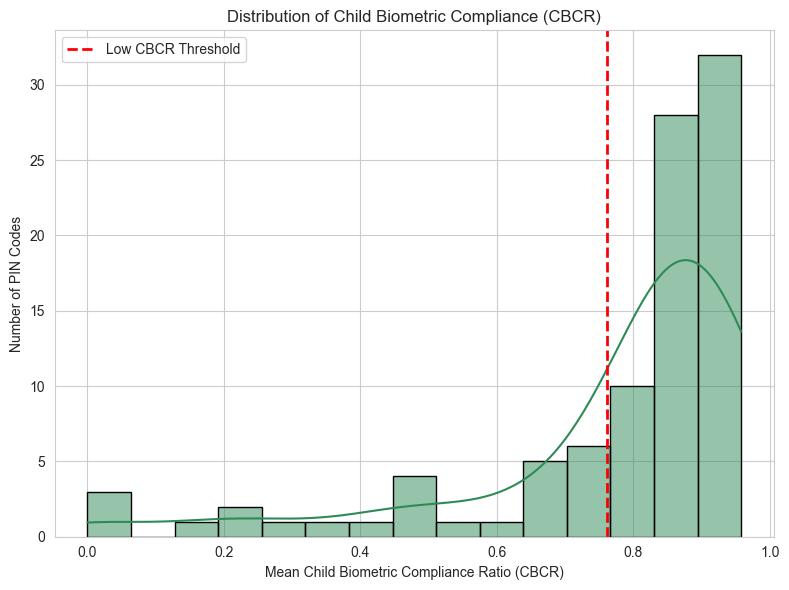

In [17]:
# Visualization 3: Child Biometric Compliance (CBCR)

plt.figure(figsize=(8, 6))

sns.histplot(
    pin['mean_CBCR'],
    bins=15,
    kde=True,
    color='seagreen',
    edgecolor='black'
)

# Reference line: Low CBCR threshold (25th percentile)
cbcr_cutoff = pin['mean_CBCR'].quantile(0.25)
plt.axvline(
    cbcr_cutoff,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Low CBCR Threshold'
)

plt.title("Distribution of Child Biometric Compliance (CBCR)")
plt.xlabel("Mean Child Biometric Compliance Ratio (CBCR)")
plt.ylabel("Number of PIN Codes")
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
# Numeric outputs for CBCR distribution
# Run and paste the console output here for validation or to pick exact PINs for the doc.

pd.options.display.float_format = '{:.3f}'.format
cbcr_cutoff = pin['mean_CBCR'].quantile(0.25)

print("CBCR thresholds & summary")
# print("-------------------------")
print(f" - Low CBCR threshold (25th pct): {cbcr_cutoff:.3f}")
# print()
# print("CBCR descriptive summary (mean_CBCR):")
# print(pin['mean_CBCR'].describe(percentiles=[0.10,0.25,0.5,0.75,0.90]).to_string())
# print()

# Counts
total_pins = len(pin)
num_below = (pin['mean_CBCR'] <= cbcr_cutoff).sum()
pct_below = num_below / total_pins * 100
# print("Counts:")
# print(f" - Total PINs: {total_pins}")
# print(f" - PINs at or below 25th pct (low CBCR): {num_below} ({pct_below:.1f}%)")
# print()

# Top low-CBCR PINs (worst performers)
print("Top 15 PINs with lowest mean_CBCR (need priority intervention):")
cols = ['pincode','months_total','mean_CBCR','median_CBCR','low_CBCR']
print(pin.sort_values('mean_CBCR').head(15)[cols].to_string(index=False))
print()

# Top performers (for reference)
print("Top 15 PINs with highest mean_CBCR (good compliance):")
print(pin.sort_values('mean_CBCR', ascending=False).head(15)[cols].to_string(index=False))
print()

# Optional: small bin counts to match histogram bins
print("Histogram bin counts (approx, 15 bins):")
hist = pd.cut(pin['mean_CBCR'], bins=15).value_counts().sort_index()
print(hist.to_string())


CBCR thresholds & summary
 - Low CBCR threshold (25th pct): 0.761
Top 15 PINs with lowest mean_CBCR (need priority intervention):
 pincode  months_total  mean_CBCR  median_CBCR  low_CBCR
  401609             6      0.000        0.000      True
  401608             7      0.000        0.000      True
  421304             9      0.000        0.000      True
  421604             9      0.167        0.000      True
  401702             9      0.194        0.000      True
  401703             9      0.231        0.000      True
  401701             9      0.259        0.000      True
  401401             9      0.365        0.400      True
  401405             9      0.419        0.500      True
  401503             9      0.462        0.500      True
  401506             9      0.487        0.667      True
  401402             9      0.490        0.667      True
  401103             9      0.506        0.500      True
  401104             9      0.515        0.500      True
  401603       

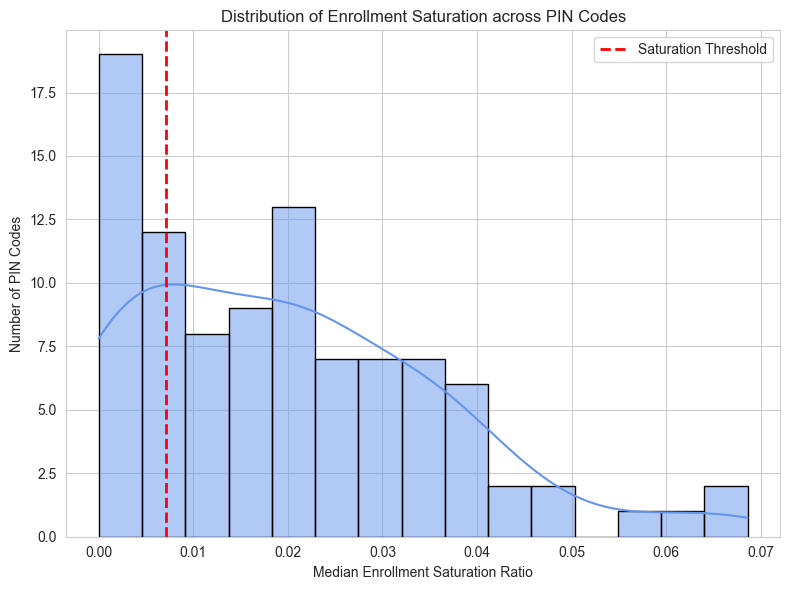

In [22]:
# Visualization 4: Enrollment Saturation Distribution

plt.figure(figsize=(8, 6))

sns.histplot(
    pin['median_ENROL_SAT'],
    bins=15,
    kde=True,
    color='cornflowerblue',
    edgecolor='black'
)

# Reference line: Saturation threshold (25th percentile)
sat_cutoff = pin['median_ENROL_SAT'].quantile(0.25)
plt.axvline(
    sat_cutoff,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Saturation Threshold'
)

plt.title("Distribution of Enrollment Saturation across PIN Codes")
plt.xlabel("Median Enrollment Saturation Ratio")
plt.ylabel("Number of PIN Codes")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Numeric outputs for Enrollment Saturation (full output, untruncated)
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 2000)
pd.set_option('display.max_colwidth', None)
pd.options.display.float_format = '{:.6f}'.format

sat_cutoff = pin['median_ENROL_SAT'].quantile(0.25)

print("=== Thresholds & Summary ===")
print(f"Low saturation threshold (25th percentile of median_ENROL_SAT): {sat_cutoff:.6f}")
# print()
# print("Descriptive summary for median_ENROL_SAT:")
# print(pin['median_ENROL_SAT'].describe(percentiles=[0.10,0.25,0.50,0.75,0.90]).to_string())
# print()

# Counts
total_pins = len(pin)
num_saturated = pin['is_saturated'].sum()
pct_saturated = num_saturated / total_pins * 100
print("=== Counts ===")
print(f"Total PINs: {total_pins}")
print(f"PINs flagged is_saturated == True: {num_saturated} ({pct_saturated:.1f}%)")
print(f"PINs at or below 25th pct median_ENROL_SAT (same as is_saturated logic): {(pin['median_ENROL_SAT'] <= sat_cutoff).sum()}")
print()

# Top worst (highest enrol_sat) and top most-saturated (lowest enrol_sat)
print("=== Top 10 PINs with HIGHEST median_ENROL_SAT (still enrolling) ===")
cols = ['pincode','months_total','median_ENROL_SAT','mean_ENROL_SAT','is_saturated']
print(pin.sort_values('median_ENROL_SAT', ascending=False)[cols].head(10).to_string(index=False))
print()

print("=== Top 20 PINs with LOWEST median_ENROL_SAT (most saturated) ===")
print(pin.sort_values('median_ENROL_SAT', ascending=True)[cols].head(20).to_string(index=False))
print()

# Exact histogram bin counts matching the plot (15 bins)
print("=== Histogram bin counts (15 bins) ===")
hist = pd.cut(pin['median_ENROL_SAT'], bins=15)
hist_counts = hist.value_counts().sort_index()
print(hist_counts.to_string())
print()

# Full table of saturation columns for cross-check / export
print("=== Full saturation table (pincode, months_total, mean_ENROL_SAT, median_ENROL_SAT, is_saturated) ===")
print(pin[['pincode','months_total','mean_ENROL_SAT','median_ENROL_SAT','is_saturated']].round(6).to_string(index=False))


=== Thresholds & Summary ===
Low saturation threshold (25th percentile of median_ENROL_SAT): 0.007101
=== Counts ===
Total PINs: 96
PINs flagged is_saturated == True: 24 (25.0%)
PINs at or below 25th pct median_ENROL_SAT (same as is_saturated logic): 24

=== Top 10 PINs with HIGHEST median_ENROL_SAT (still enrolling) ===
 pincode  months_total  median_ENROL_SAT  mean_ENROL_SAT  is_saturated
  421503            11          0.068619        0.112179         False
  421302            11          0.065943        0.071183         False
  401107            11          0.061328        0.066026         False
  400612            11          0.056814        0.064679         False
  421501            11          0.048345        0.102711         False
  421203            11          0.046899        0.042443         False
  400601            11          0.045302        0.041322         False
  421306            11          0.042381        0.054131         False
  421102            11          0.0408

In [29]:
monthly.columns

Index(['state', 'district', 'pincode', 'month', 'age_0_5', 'age_5_17', 'age_18_greater', 'demo_age_5_17', 'demo_age_17_', 'bio_age_5_17', 'bio_age_17_'], dtype='object')

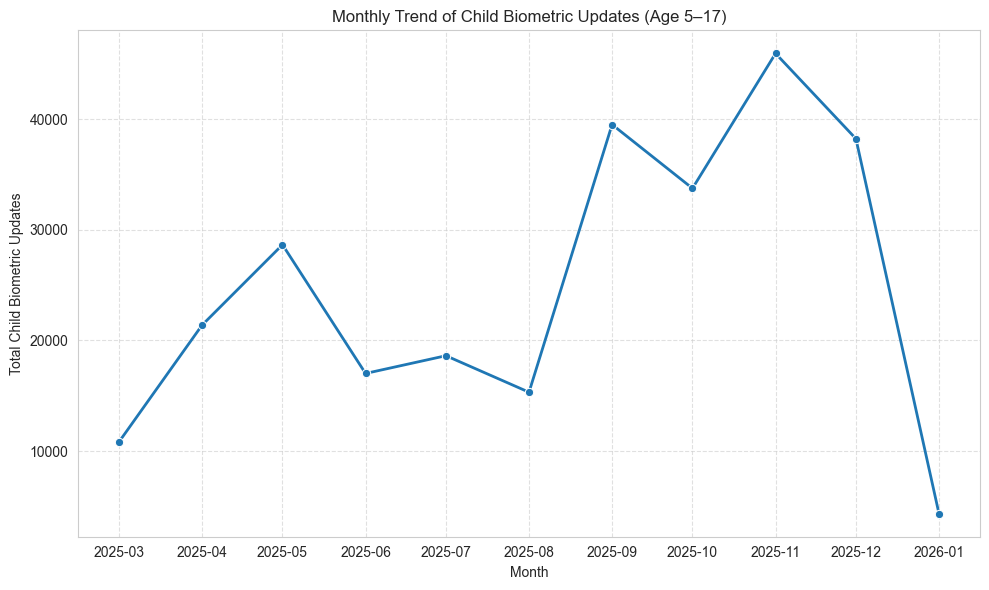

In [30]:
# Visualization 5: Monthly Seasonality of Child Biometric Updates
# (Recomputing total_txn using correct formula)

# ensure month is datetime
monthly['month'] = pd.to_datetime(monthly['month'])

# compute new enrolments
monthly['new_enrol'] = (
    monthly['age_0_5'] +
    monthly['age_5_17'] +
    monthly['age_18_greater']
)

# compute total transactions (CORRECT formula)
monthly['total_txn'] = (
    monthly['new_enrol'] +
    monthly['demo_age_5_17'] +
    monthly['demo_age_17_'] +
    monthly['bio_age_5_17'] +
    monthly['bio_age_17_']
)

# aggregate month-wise
monthly_trend = (
    monthly.groupby('month')
    .agg(
        total_child_bio_updates=('bio_age_5_17', 'sum'),
        total_transactions=('total_txn', 'sum')
    )
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=monthly_trend,
    x='month',
    y='total_child_bio_updates',
    marker='o',
    linewidth=2
)

plt.title("Monthly Trend of Child Biometric Updates (Age 5–17)")
plt.xlabel("Month")
plt.ylabel("Total Child Biometric Updates")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
